In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi']  = 120
plt.rcParams['font.family'] = 'DejaVu Sans'

print("✅ All Libraries Loaded!")
print("🛍️  Customer Segmentation — K-Means Ready!")

✅ All Libraries Loaded!
🛍️  Customer Segmentation — K-Means Ready!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os

ZIP = '/content/drive/MyDrive/ProdigyInternshipdatasets/t2.zip'

with zipfile.ZipFile(ZIP, 'r') as z:
    z.extractall('/content/task2/')

print("✅ Extracted!")
print(f"📁 Contents: {os.listdir('/content/task2/')}")

CSV = None
for root, dirs, files in os.walk('/content/task2/'):
    for f in files:
        if f.endswith('.csv'):
            CSV = os.path.join(root, f)
            print(f"✅ CSV Found : {CSV}")

df = pd.read_csv(CSV)
print(f"\n📦 Dataset Loaded!")
print(f"👥 Total Customers : {df.shape[0]}")
print(f"📋 Total Columns   : {df.shape[1]}")
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Extracted!
📁 Contents: ['Mall_Customers.csv']
✅ CSV Found : /content/task2/Mall_Customers.csv

📦 Dataset Loaded!
👥 Total Customers : 200
📋 Total Columns   : 5


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.columns = ['CustomerID', 'Gender', 'Age', 'AnnualIncome', 'SpendingScore']

print("📊 Dataset Info:")
print(f"  Shape         : {df.shape}")
print(f"  Missing Values: {df.isnull().sum().sum()}")
print(f"  👨 Male       : {(df['Gender']=='Male').sum()}")
print(f"  👩 Female     : {(df['Gender']=='Female').sum()}")
print("\n📈 Basic Statistics:")
df.describe().round(2)

📊 Dataset Info:
  Shape         : (200, 5)
  Missing Values: 0
  👨 Male       : 88
  👩 Female     : 112

📈 Basic Statistics:


,CustomerID,Age,AnnualIncome,SpendingScore
count,200.00,200.00,200.00,200.00
mean,100.50,38.85,60.56,50.20
std,57.88,13.97,26.26,25.82
min,1.00,18.00,15.00,1.00
25%,50.75,28.75,41.50,34.75
50%,100.50,36.00,61.50,50.00
75%,150.25,49.00,78.00,73.00
max,200.00,70.00,137.00,99.00


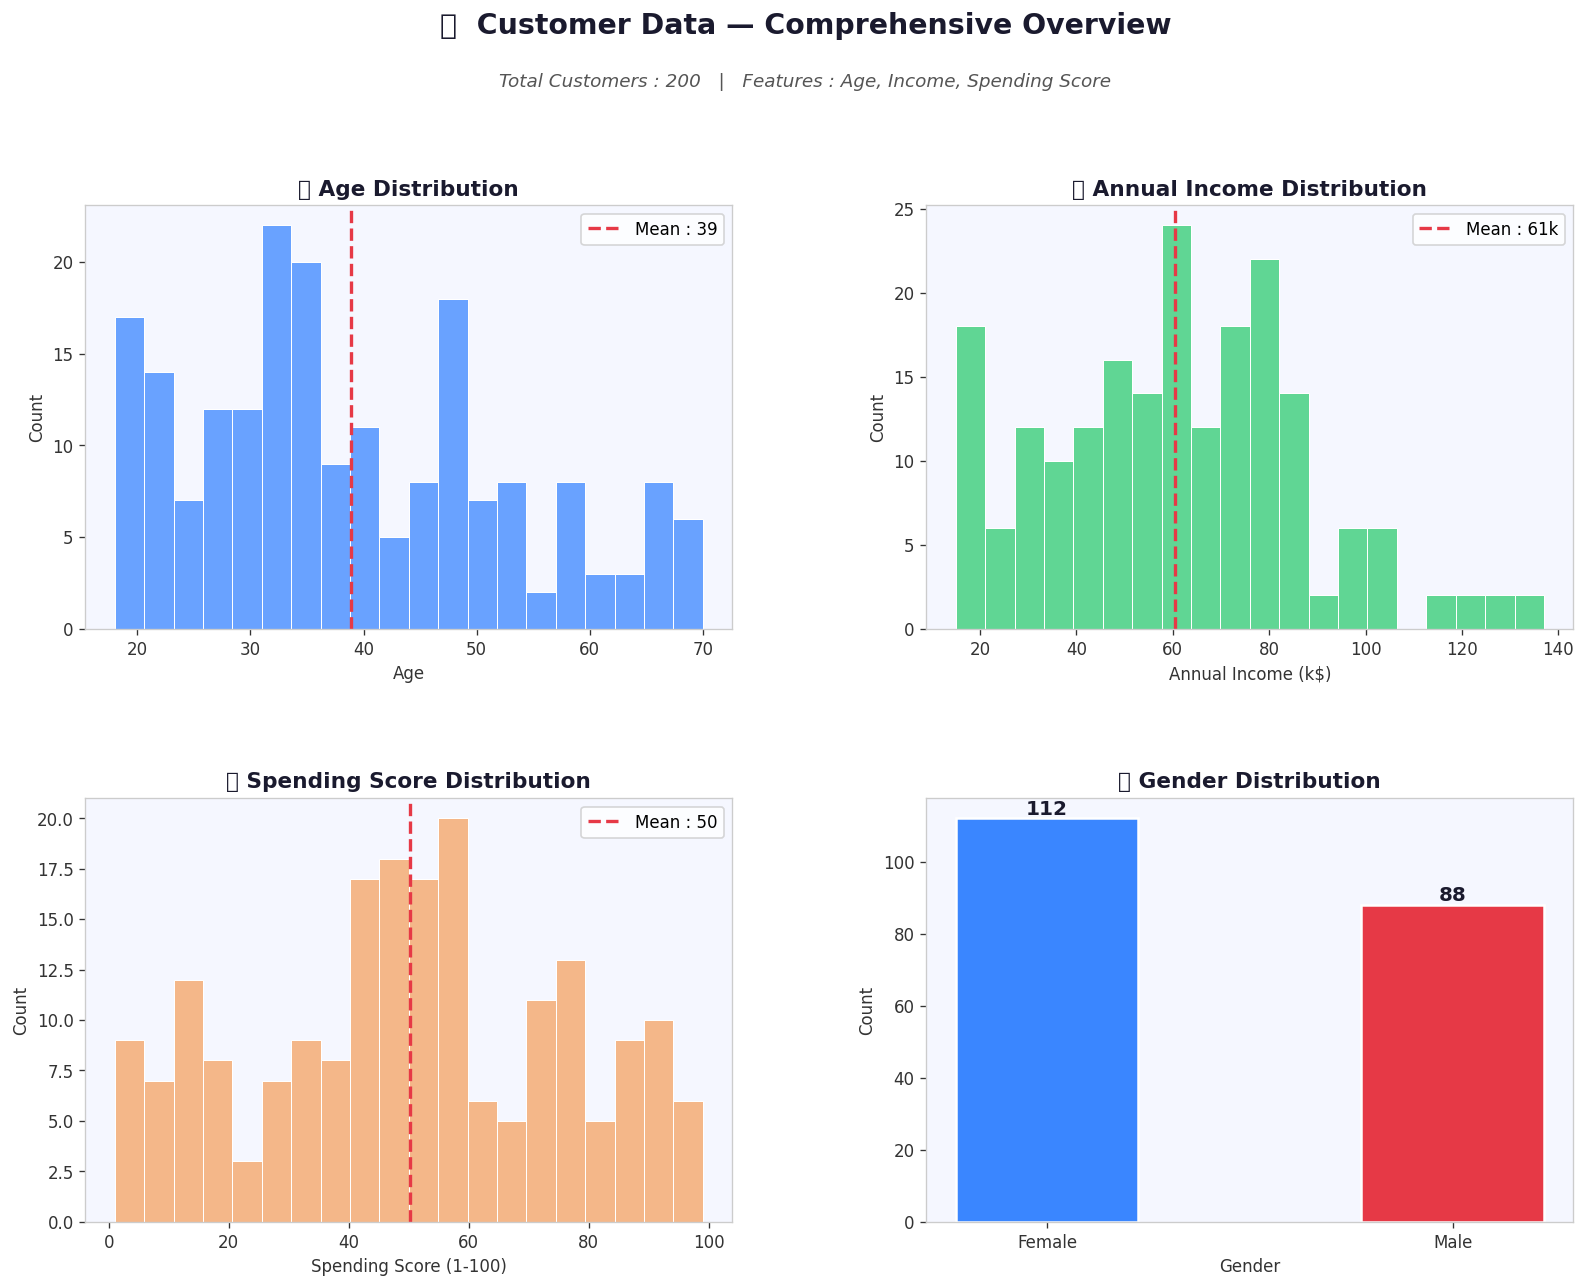

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.patch.set_facecolor('white')
fig.text(0.5, 1.01, '🛍️  Customer Data — Comprehensive Overview',
         ha='center', fontsize=17, fontweight='bold', color='#1a1a2e')
fig.text(0.5, 0.97, f'Total Customers : {len(df)}   |   Features : Age, Income, Spending Score',
         ha='center', fontsize=11, color='#555555', style='italic')

axes[0,0].set_facecolor('#f5f7ff')
sns.histplot(df['Age'], bins=20, color='#3a86ff',
             ax=axes[0,0], edgecolor='white', linewidth=0.6)
axes[0,0].set_title('🎂 Age Distribution', fontweight='bold',
                     color='#1a1a2e', fontsize=13)
axes[0,0].set_xlabel('Age', color='#333333')
axes[0,0].set_ylabel('Count', color='#333333')
axes[0,0].tick_params(colors='#333333')
axes[0,0].axvline(df['Age'].mean(), color='#e63946',
                   linestyle='--', linewidth=2,
                   label=f"Mean : {df['Age'].mean():.0f}")
axes[0,0].legend(facecolor='white', edgecolor='#cccccc')
for s in axes[0,0].spines.values():
    s.set_color('#cccccc')

axes[0,1].set_facecolor('#f5f7ff')
sns.histplot(df['AnnualIncome'], bins=20, color='#2ecc71',
             ax=axes[0,1], edgecolor='white', linewidth=0.6)
axes[0,1].set_title('💵 Annual Income Distribution', fontweight='bold',
                     color='#1a1a2e', fontsize=13)
axes[0,1].set_xlabel('Annual Income (k$)', color='#333333')
axes[0,1].set_ylabel('Count', color='#333333')
axes[0,1].tick_params(colors='#333333')
axes[0,1].axvline(df['AnnualIncome'].mean(), color='#e63946',
                   linestyle='--', linewidth=2,
                   label=f"Mean : {df['AnnualIncome'].mean():.0f}k")
axes[0,1].legend(facecolor='white', edgecolor='#cccccc')
for s in axes[0,1].spines.values():
    s.set_color('#cccccc')

axes[1,0].set_facecolor('#f5f7ff')
sns.histplot(df['SpendingScore'], bins=20, color='#f4a261',
             ax=axes[1,0], edgecolor='white', linewidth=0.6)
axes[1,0].set_title('🛒 Spending Score Distribution', fontweight='bold',
                     color='#1a1a2e', fontsize=13)
axes[1,0].set_xlabel('Spending Score (1-100)', color='#333333')
axes[1,0].set_ylabel('Count', color='#333333')
axes[1,0].tick_params(colors='#333333')
axes[1,0].axvline(df['SpendingScore'].mean(), color='#e63946',
                   linestyle='--', linewidth=2,
                   label=f"Mean : {df['SpendingScore'].mean():.0f}")
axes[1,0].legend(facecolor='white', edgecolor='#cccccc')
for s in axes[1,0].spines.values():
    s.set_color('#cccccc')

axes[1,1].set_facecolor('#f5f7ff')
gender_counts = df['Gender'].value_counts()
bars = axes[1,1].bar(gender_counts.index, gender_counts.values,
                      color=['#3a86ff','#e63946'],
                      edgecolor='white', linewidth=1.5, width=0.45)
axes[1,1].set_title('👫 Gender Distribution', fontweight='bold',
                     color='#1a1a2e', fontsize=13)
axes[1,1].set_xlabel('Gender', color='#333333')
axes[1,1].set_ylabel('Count',  color='#333333')
axes[1,1].tick_params(colors='#333333')
for bar, val in zip(bars, gender_counts.values):
    axes[1,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 1, str(val),
                   ha='center', fontweight='bold',
                   fontsize=12, color='#1a1a2e')
for s in axes[1,1].spines.values():
    s.set_color('#cccccc')

plt.subplots_adjust(wspace=0.3, hspace=0.4)
plt.show()

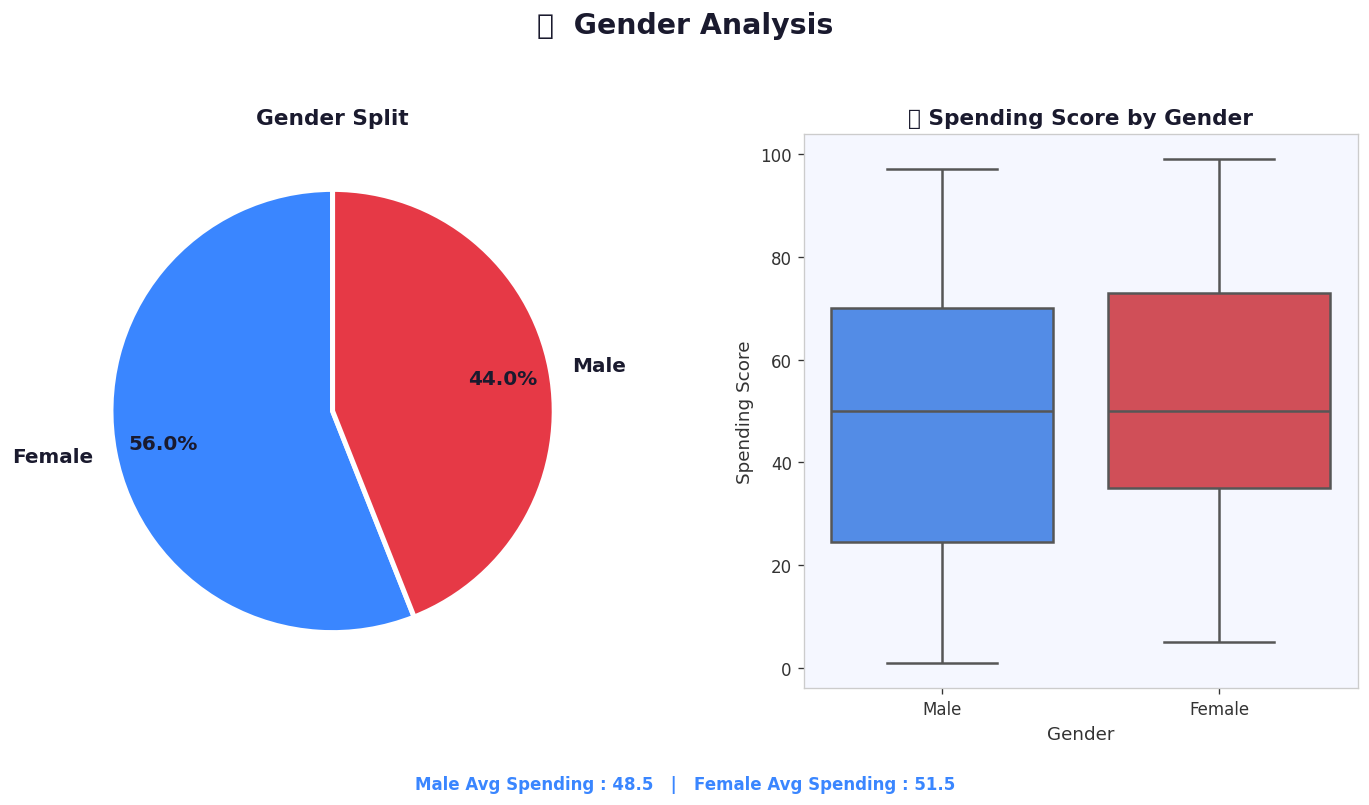

In [ ]:
gender_counts = df['Gender'].value_counts()
colors_g      = ['#3a86ff', '#e63946']

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('white')
fig.text(0.5, 1.02, '👥  Gender Analysis',
         ha='center', fontsize=17, fontweight='bold', color='#1a1a2e')

axes[0].set_facecolor('#f5f7ff')
wedges, texts, pcts = axes[0].pie(
    gender_counts,
    labels=gender_counts.index,
    autopct='%1.1f%%',
    colors=colors_g, startangle=90,
    pctdistance=0.78,
    wedgeprops={'edgecolor': 'white', 'linewidth': 3},
    textprops={'fontsize': 12, 'fontweight': 'bold', 'color': '#1a1a2e'}
)
axes[0].set_title('Gender Split', fontweight='bold',
                   color='#1a1a2e', fontsize=13)

axes[1].set_facecolor('#f5f7ff')
sns.boxplot(x='Gender', y='SpendingScore', data=df,
            ax=axes[1], palette={'Male':'#3a86ff','Female':'#e63946'},
            linewidth=1.5)
axes[1].set_title('💳 Spending Score by Gender',
                   fontweight='bold', color='#1a1a2e', fontsize=13)
axes[1].set_xlabel('Gender',         color='#333333', fontsize=11)
axes[1].set_ylabel('Spending Score', color='#333333', fontsize=11)
axes[1].tick_params(colors='#333333')
for s in axes[1].spines.values():
    s.set_color('#cccccc')

male_avg   = df[df['Gender']=='Male']['SpendingScore'].mean()
female_avg = df[df['Gender']=='Female']['SpendingScore'].mean()
fig.text(0.5, -0.03,
         f'Male Avg Spending : {male_avg:.1f}   |   Female Avg Spending : {female_avg:.1f}',
         ha='center', fontsize=10, color='#3a86ff', fontweight='bold')

plt.subplots_adjust(wspace=0.35)
plt.show()

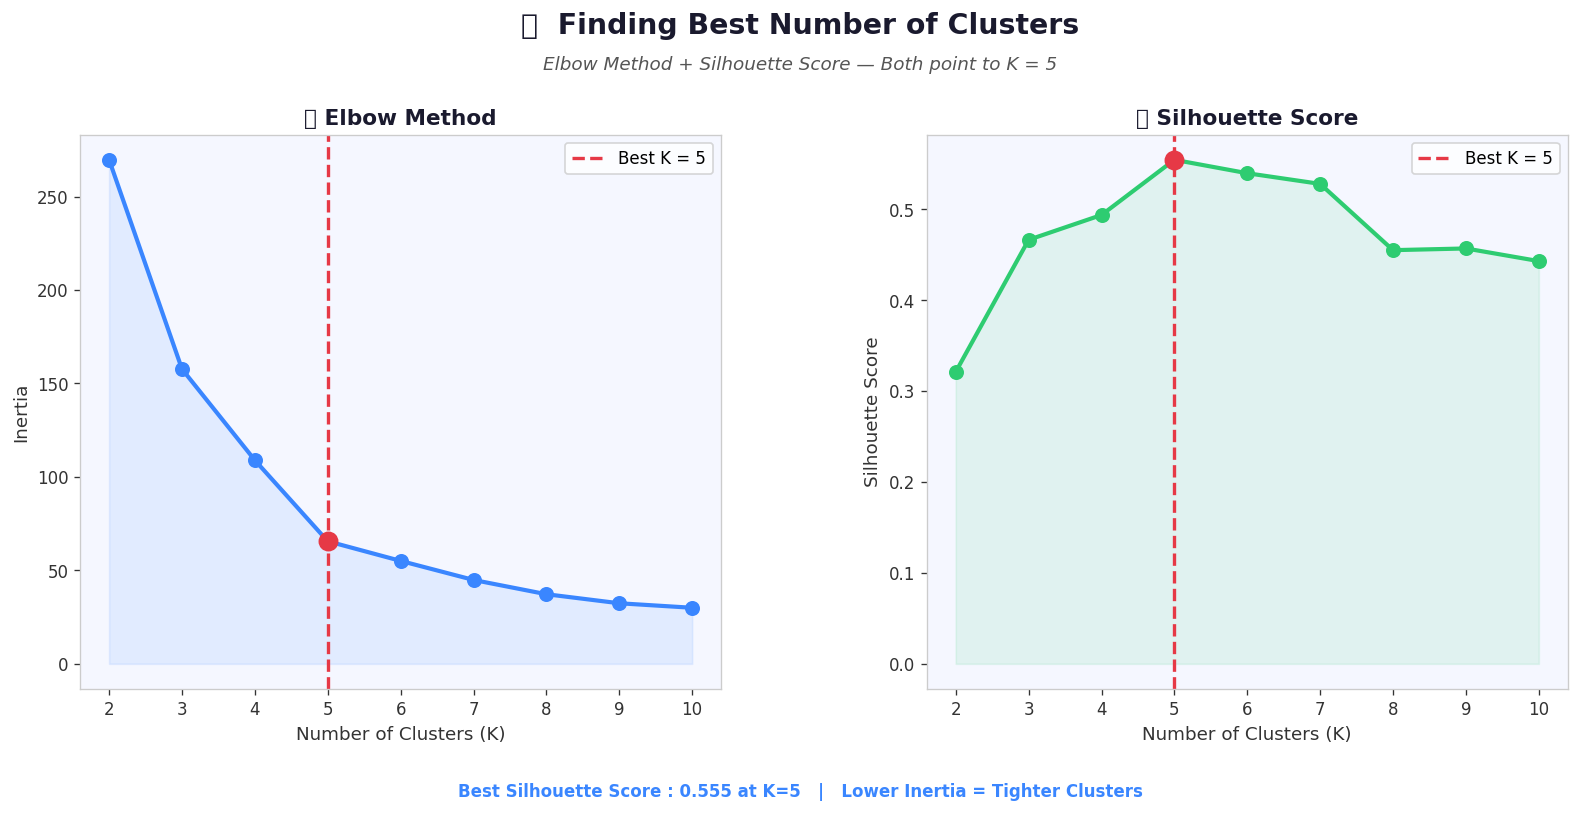

✅ Best K = 5   |   Silhouette : 0.555


In [ ]:
X      = df[['AnnualIncome', 'SpendingScore']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

inertia    = []
silhouette = []
K_range    = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
    silhouette.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('white')
fig.text(0.5, 1.02, '🔍  Finding Best Number of Clusters',
         ha='center', fontsize=17, fontweight='bold', color='#1a1a2e')
fig.text(0.5, 0.97, 'Elbow Method + Silhouette Score — Both point to K = 5',
         ha='center', fontsize=11, color='#555555', style='italic')

axes[0].set_facecolor('#f5f7ff')
axes[0].plot(K_range, inertia, marker='o', linestyle='-',
             linewidth=2.5, markersize=8, color='#3a86ff')
axes[0].fill_between(K_range, inertia, alpha=0.1, color='#3a86ff')
axes[0].axvline(x=5, color='#e63946', linestyle='--',
                linewidth=2, label='Best K = 5')
axes[0].scatter([5], [inertia[3]], color='#e63946', s=120, zorder=5)
axes[0].set_title('📉 Elbow Method',
                   fontweight='bold', color='#1a1a2e', fontsize=13)
axes[0].set_xlabel('Number of Clusters (K)', color='#333333', fontsize=11)
axes[0].set_ylabel('Inertia',                color='#333333', fontsize=11)
axes[0].tick_params(colors='#333333')
axes[0].legend(facecolor='white', edgecolor='#cccccc', fontsize=10)
for s in axes[0].spines.values():
    s.set_color('#cccccc')

axes[1].set_facecolor('#f5f7ff')
axes[1].plot(K_range, silhouette, marker='o', linestyle='-',
             linewidth=2.5, markersize=8, color='#2ecc71')
axes[1].fill_between(K_range, silhouette, alpha=0.1, color='#2ecc71')
axes[1].axvline(x=5, color='#e63946', linestyle='--',
                linewidth=2, label='Best K = 5')
axes[1].scatter([5], [silhouette[3]], color='#e63946', s=120, zorder=5)
axes[1].set_title('📊 Silhouette Score',
                   fontweight='bold', color='#1a1a2e', fontsize=13)
axes[1].set_xlabel('Number of Clusters (K)', color='#333333', fontsize=11)
axes[1].set_ylabel('Silhouette Score',        color='#333333', fontsize=11)
axes[1].tick_params(colors='#333333')
axes[1].legend(facecolor='white', edgecolor='#cccccc', fontsize=10)
for s in axes[1].spines.values():
    s.set_color('#cccccc')

fig.text(0.5, -0.04,
         f'Best Silhouette Score : {max(silhouette):.3f} at K=5   |   Lower Inertia = Tighter Clusters',
         ha='center', fontsize=10, color='#3a86ff', fontweight='bold')

plt.subplots_adjust(wspace=0.32)
plt.show()
print(f"✅ Best K = 5   |   Silhouette : {silhouette[3]:.3f}")

In [ ]:
kmeans       = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)
centers      = scaler.inverse_transform(kmeans.cluster_centers_)

colors = ['#e74c3c','#3498db','#2ecc71','#f39c12','#9b59b6']
labels = ['Low Income Low Spend',  'Low Income High Spend',
          'Mid Income Mid Spend',   'High Income Low Spend',
          'High Income High Spend']

print("✅ K-Means Done!")
print(f"\n{'Cluster':<10} {'Avg Income':>12} {'Avg Spending':>14}")
print("─" * 38)
for i, c in enumerate(centers):
    print(f"  {i:<10} {c[0]:>10.1f}k  {c[1]:>12.1f}")
print(f"\n👥 Customers per Cluster:")
print(df['Cluster'].value_counts().sort_index().to_string())

✅ K-Means Done!

Cluster      Avg Income   Avg Spending
──────────────────────────────────────
  0                55.3k          49.5
  1                86.5k          82.1
  2                25.7k          79.4
  3                88.2k          17.1
  4                26.3k          20.9

👥 Customers per Cluster:
Cluster
0    81
1    39
2    22
3    35
4    23


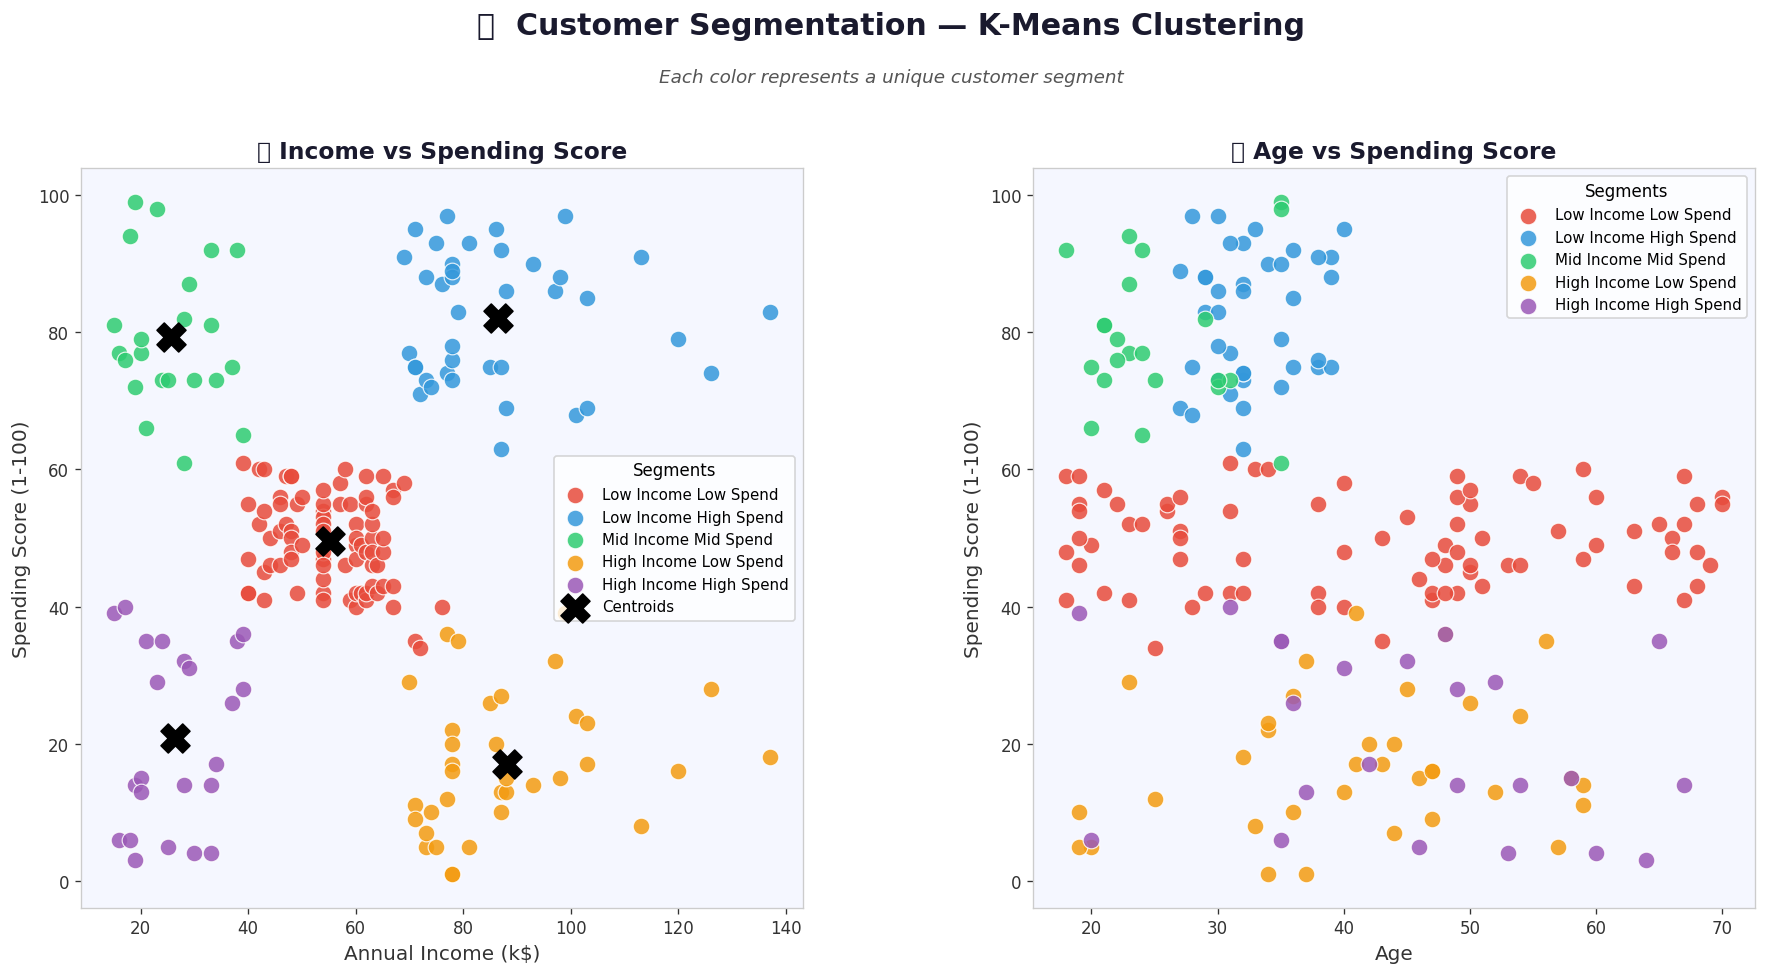

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.patch.set_facecolor('white')
fig.text(0.5, 1.02, '🛍️  Customer Segmentation — K-Means Clustering',
         ha='center', fontsize=18, fontweight='bold', color='#1a1a2e')
fig.text(0.5, 0.97, 'Each color represents a unique customer segment',
         ha='center', fontsize=11, color='#555555', style='italic')

axes[0].set_facecolor('#f5f7ff')
for i in range(5):
    mask = df['Cluster'] == i
    axes[0].scatter(df[mask]['AnnualIncome'],
                    df[mask]['SpendingScore'],
                    c=colors[i], s=100, alpha=0.85,
                    edgecolors='white', linewidth=0.7,
                    label=labels[i])
axes[0].scatter(centers[:, 0], centers[:, 1],
                c='black', s=300, marker='X',
                zorder=5, label='Centroids')
axes[0].set_title('📍 Income vs Spending Score',
                   fontweight='bold', color='#1a1a2e', fontsize=14)
axes[0].set_xlabel('Annual Income (k$)',     color='#333333', fontsize=12)
axes[0].set_ylabel('Spending Score (1-100)', color='#333333', fontsize=12)
axes[0].tick_params(colors='#333333')
axes[0].legend(title='Segments', fontsize=9,
               facecolor='white', edgecolor='#cccccc')
for s in axes[0].spines.values():
    s.set_color('#cccccc')

axes[1].set_facecolor('#f5f7ff')
for i in range(5):
    mask = df['Cluster'] == i
    axes[1].scatter(df[mask]['Age'],
                    df[mask]['SpendingScore'],
                    c=colors[i], s=100, alpha=0.85,
                    edgecolors='white', linewidth=0.7,
                    label=labels[i])
axes[1].set_title('📍 Age vs Spending Score',
                   fontweight='bold', color='#1a1a2e', fontsize=14)
axes[1].set_xlabel('Age',                   color='#333333', fontsize=12)
axes[1].set_ylabel('Spending Score (1-100)', color='#333333', fontsize=12)
axes[1].tick_params(colors='#333333')
axes[1].legend(title='Segments', fontsize=9,
               facecolor='white', edgecolor='#cccccc')
for s in axes[1].spines.values():
    s.set_color('#cccccc')

plt.subplots_adjust(wspace=0.32)
plt.show()

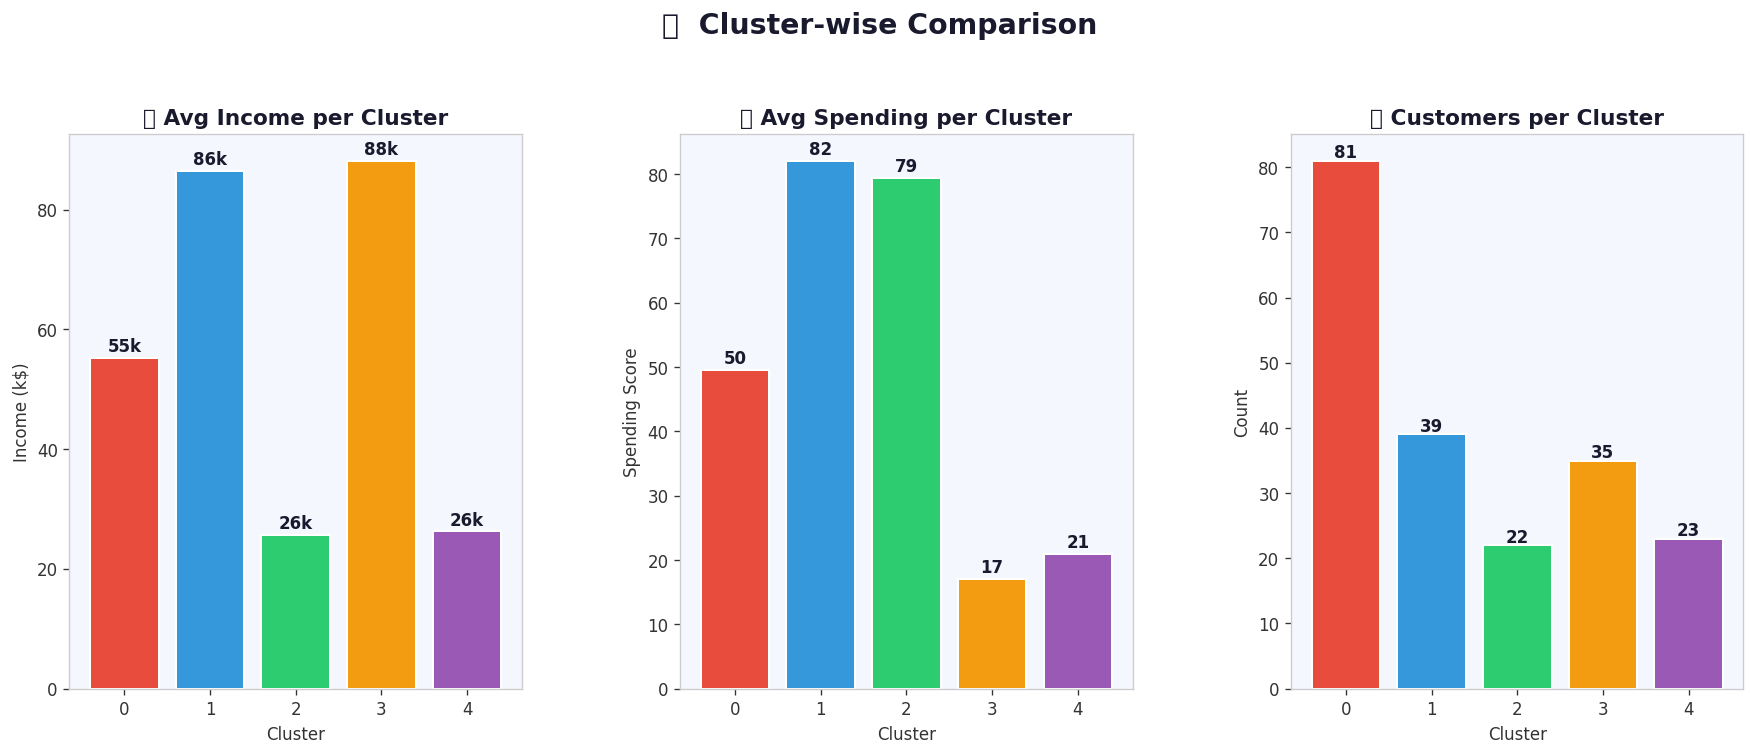

📊 Cluster Summary:
         Total_Customers  Avg_Age  Avg_Income  Avg_Spending
Cluster                                                    
0                     81     42.7        55.3          49.5
1                     39     32.7        86.5          82.1
2                     22     25.3        25.7          79.4
3                     35     41.1        88.2          17.1
4                     23     45.2        26.3          20.9


In [ ]:
cluster_summary = df.groupby('Cluster').agg(
    Total_Customers = ('CustomerID',   'count'),
    Avg_Age         = ('Age',          'mean'),
    Avg_Income      = ('AnnualIncome', 'mean'),
    Avg_Spending    = ('SpendingScore','mean')
).round(1)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.patch.set_facecolor('white')
fig.text(0.5, 1.02, '📊  Cluster-wise Comparison',
         ha='center', fontsize=17, fontweight='bold', color='#1a1a2e')

axes[0].set_facecolor('#f5f7ff')
bars = axes[0].bar(cluster_summary.index,
                   cluster_summary['Avg_Income'],
                   color=colors, edgecolor='white', linewidth=1.2)
axes[0].set_title('💵 Avg Income per Cluster',
                   fontweight='bold', color='#1a1a2e', fontsize=13)
axes[0].set_xlabel('Cluster', color='#333333')
axes[0].set_ylabel('Income (k$)', color='#333333')
axes[0].tick_params(colors='#333333')
for i, v in enumerate(cluster_summary['Avg_Income']):
    axes[0].text(i, v + 1, f'{v:.0f}k', ha='center',
                 fontweight='bold', fontsize=10, color='#1a1a2e')
for s in axes[0].spines.values():
    s.set_color('#cccccc')

axes[1].set_facecolor('#f5f7ff')
axes[1].bar(cluster_summary.index,
            cluster_summary['Avg_Spending'],
            color=colors, edgecolor='white', linewidth=1.2)
axes[1].set_title('🛒 Avg Spending per Cluster',
                   fontweight='bold', color='#1a1a2e', fontsize=13)
axes[1].set_xlabel('Cluster',        color='#333333')
axes[1].set_ylabel('Spending Score', color='#333333')
axes[1].tick_params(colors='#333333')
for i, v in enumerate(cluster_summary['Avg_Spending']):
    axes[1].text(i, v + 1, f'{v:.0f}', ha='center',
                 fontweight='bold', fontsize=10, color='#1a1a2e')
for s in axes[1].spines.values():
    s.set_color('#cccccc')

axes[2].set_facecolor('#f5f7ff')
axes[2].bar(cluster_summary.index,
            cluster_summary['Total_Customers'],
            color=colors, edgecolor='white', linewidth=1.2)
axes[2].set_title('👥 Customers per Cluster',
                   fontweight='bold', color='#1a1a2e', fontsize=13)
axes[2].set_xlabel('Cluster', color='#333333')
axes[2].set_ylabel('Count',   color='#333333')
axes[2].tick_params(colors='#333333')
for i, v in enumerate(cluster_summary['Total_Customers']):
    axes[2].text(i, v + 0.5, str(v), ha='center',
                 fontweight='bold', fontsize=10, color='#1a1a2e')
for s in axes[2].spines.values():
    s.set_color('#cccccc')

plt.subplots_adjust(wspace=0.35)
plt.show()

print("📊 Cluster Summary:")
print(cluster_summary.to_string())

In [ ]:
segment_names = {
    0: 'Low Income,  Low Spender',
    1: 'Low Income,  High Spender',
    2: 'Average Customer',
    3: 'High Income, Low Spender',
    4: 'High Income, High Spender'
}

W   = 50
top = "╔" + "═" * W + "╗"
mid = "╠" + "═" * W + "╣"
bot = "╚" + "═" * W + "╝"

def section(title):
    pad_l = (W - len(title)) // 2
    pad_r =  W - len(title) - pad_l
    return f"║{' ' * pad_l}{title}{' ' * pad_r}║"

def row(label, value):
    content = f"  {label:<22} :  {value}"
    pad     = W - len(content)
    return f"║{content}{' ' * pad}║"

print()
print(top)
print(section("CUSTOMER SEGMENTATION  --  FINAL REPORT"))
print(mid)
print(section("---  Configuration  ---"))
print(mid)
print(row("Dataset",       "Mall Customers"))
print(row("Total Customers", f"{len(df)}"))
print(row("Algorithm",     "K-Means Clustering"))
print(row("clusters  K",   "5"))
print(row("Features",      "Income + Spending Score"))
print(mid)
print(section("---  Cluster Results  ---"))
print(mid)
for idx, r in cluster_summary.iterrows():
    print(row(f"Cluster {idx}", segment_names[idx]))
    print(row(f"  Customers", f"{int(r.Total_Customers)}"))
    print(row(f"  Avg Age",   f"{r.Avg_Age:.0f} years"))
    print(row(f"  Avg Income",f"${r.Avg_Income:.0f}k"))
    print(row(f"  Avg Spend", f"{r.Avg_Spending:.0f}/100"))
    if idx < 4:
        print(mid)
print(mid)
print(section("TASK 02  --  COMPLETED SUCCESSFULLY"))
print(bot)


╔══════════════════════════════════════════════════╗
║     CUSTOMER SEGMENTATION  --  FINAL REPORT      ║
╠══════════════════════════════════════════════════╣
║             ---  Configuration  ---              ║
╠══════════════════════════════════════════════════╣
║  Dataset                :  Mall Customers        ║
║  Total Customers        :  200                   ║
║  Algorithm              :  K-Means Clustering    ║
║  clusters  K            :  5                     ║
║  Features               :  Income + Spending Score║
╠══════════════════════════════════════════════════╣
║            ---  Cluster Results  ---             ║
╠══════════════════════════════════════════════════╣
║  Cluster 0              :  Low Income,  Low Spender║
║    Customers            :  81                    ║
║    Avg Age              :  43 years              ║
║    Avg Income           :  $55k                  ║
║    Avg Spend            :  50/100                ║
╠═════════════════════════════════════════